In [1]:
import os
import json
import torchxrayvision as xrv

In [2]:
data_path = '/home/people/24109678/scratch/machex_dataset/mimic'

In [3]:
with open(os.path.join(data_path,'index.json'),'r') as f:
    metadata = json.load(f)

In [76]:
import random
idx = random.randint(0,30000)
print(idx)
sample = metadata[list(metadata.keys())[idx]]
sample

29040


{'path': '/home/people/24109678/scratch/machex_dataset/mimic/02/029040.jpg',
 'key': 'files/p18/p18591277/s50449935/6dd50787-23d1f133-c79dd132-ccc8c956-bee8f68a.jpg',
 'class_label': [0, 1, 0, 0, -1, 0, -1, 0, 0, -1, 0, 0, 0],
 'prompt': 'A chest x-ray image ,with Cardiomegaly ,with no Edema ,with no Pneumonia ,with no Pleural Effusion ',
 'report': 'Normal lung volumes. Mildly enlarged size of the cardiac silhouette without pulmonary edema or other lung parenchymal changes. No pneumonia, no pleural effusions. No hilar or mediastinal abnormalities. In particular, the right upper lobe appears unremarkable.'}

In [77]:
p = sample['path']

p = os.path.join(os.path.dirname(p), os.path.splitext(os.path.basename(p))[0] +'_cheff.jpg')

In [78]:
import numpy as np
from PIL import Image

img_org = Image.open(sample['path'])
img_ai = Image.open(p)

img_org = np.array(img_org)
img_ai = np.array(img_ai)

img_org = xrv.datasets.normalize(img_org,255)
img_org = img_org.mean(2)[None,...]

img_ai = xrv.datasets.normalize(img_ai,255)
img_ai = img_ai.mean(2)[None,...]

In [79]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform_clf = transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(224)])

In [80]:
def show_images(img_org, img_ai):
    # img_org = transform_clf(img_org)
    # img_ai = transform_clf(img_ai)

    plt.subplot(1,2,1)
    plt.imshow(img_org.transpose(1,2,0),cmap='gray')

    plt.subplot(1,2,2)
    plt.imshow(img_ai.transpose(1,2,0),cmap='gray')

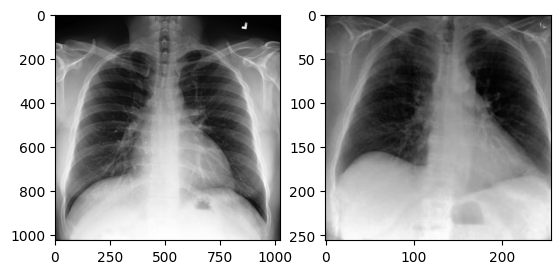

In [81]:
show_images(img_org, img_ai)

In [82]:
cache_dir = "/home/people/24109678/scratch/Code/CXR-Soft-labels/weights"
model_mimic = xrv.models.DenseNet(weights="densenet121-res224-mimic_nb",cache_dir=cache_dir)
model_cxr = xrv.models.DenseNet(weights="densenet121-res224-chex",cache_dir=cache_dir)

In [83]:
import pandas as pd

def get_class_preds(img):
    img = transform_clf(img)
    img = torch.from_numpy(img)
    outputs_mimic = model_mimic(img[None, ...])
    outputs_chexpert = model_cxr(img[None, ...])
    return pd.DataFrame(
        {
            "mimic": dict(
                zip(model_mimic.pathologies, outputs_mimic[0].detach().numpy())
            ),
            "chexpert": dict(
                zip(model_mimic.pathologies, outputs_chexpert[0].detach().numpy())
            ),
        }
    )

In [84]:
get_class_preds(img_org)

,mimic,chexpert
Atelectasis,0.129145,0.166792
Consolidation,0.159785,0.096201
,0.500000,0.500000
Pneumothorax,0.335478,0.097634
Edema,0.025531,0.292190
Effusion,0.026822,0.093089
Pneumonia,0.317447,0.123606
Cardiomegaly,0.343075,0.329678
Lung Lesion,0.252645,0.105000
Fracture,0.062047,0.168292


In [85]:
get_class_preds(img_ai)

,mimic,chexpert
Atelectasis,0.557045,0.644157
Consolidation,0.373155,0.494027
,0.500000,0.500000
Pneumothorax,0.501485,0.100439
Edema,0.118386,0.377110
Effusion,0.397063,0.397225
Pneumonia,0.448287,0.359011
Cardiomegaly,0.520365,0.604687
Lung Lesion,0.510908,0.336943
Fracture,0.507374,0.537926


In [86]:
seg_model = xrv.baseline_models.chestx_det.PSPNet(cache_dir=cache_dir)
transform_seg = transforms.Compose([xrv.datasets.XRayCenterCrop(),xrv.datasets.XRayResizer(512)])

def get_segmentation_masks(img):
    img = torch.from_numpy(img)
    img = transform_seg(img)
    output_seg = seg_model(img)
    return output_seg

In [ ]:
output_seg = 

tensor([[-6.2200, -6.2200, -6.2200,  ..., -6.8909, -6.8909, -6.8909],
        [-6.2200, -6.2200, -6.2200,  ..., -6.8909, -6.8909, -6.8909],
        [-6.2200, -6.2200, -6.2200,  ..., -6.8909, -6.8909, -6.8909],
        ...,
        [-9.1651, -9.1651, -9.1651,  ..., -8.3381, -8.3381, -8.3381],
        [-9.1651, -9.1651, -9.1651,  ..., -8.3381, -8.3381, -8.3381],
        [-9.1651, -9.1651, -9.1651,  ..., -8.3381, -8.3381, -8.3381]],
       grad_fn=<SelectBackward0>)

In [158]:
seg_model.targets

['Left Clavicle',
 'Right Clavicle',
 'Left Scapula',
 'Right Scapula',
 'Left Lung',
 'Right Lung',
 'Left Hilus Pulmonis',
 'Right Hilus Pulmonis',
 'Heart',
 'Aorta',
 'Facies Diaphragmatica',
 'Mediastinum',
 'Weasand',
 'Spine']

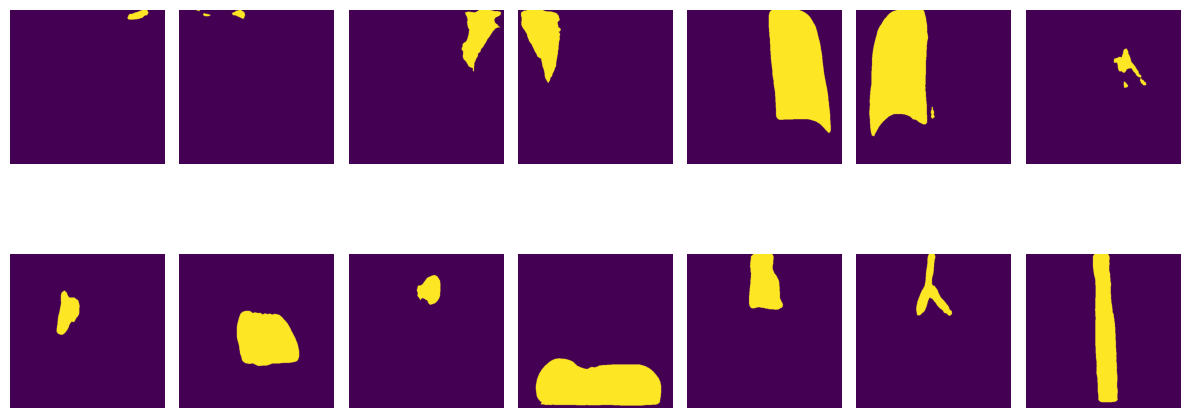

In [ ]:
def plot_seg_masks(out_seg):
   output_seg = torch.sigmoid(output_seg)
   masks = (output_seg > 0.5).float()

   fig,axs = plt.subplots(2,7,figsize = (12,6))
   axs = axs.flatten()
   for i, ax in enumerate(axs):
      ax.imshow(masks[0,i,...].detach().numpy())
      ax.set_axis_off()
   plt.tight_layout()
   plt.show()